In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from common.utils import get_path_project, load_model_and_scaler

Não foi usado um scaler!


/home/alecrim/workspace/mle-tech-challenge-4/packages/common/src/common/utils.py:87: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_mv = mlflow_client.get_latest_versions(model_name, stages=None)[0]


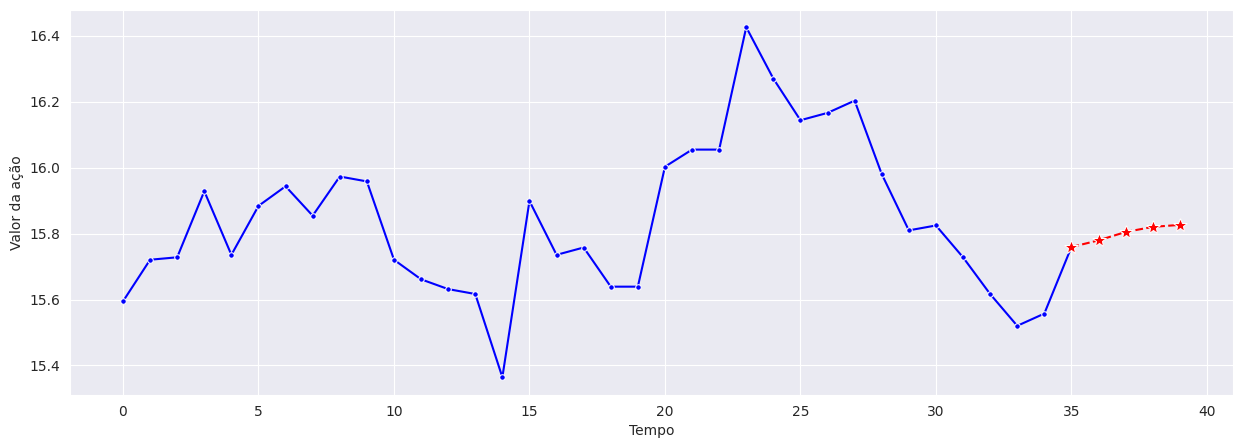

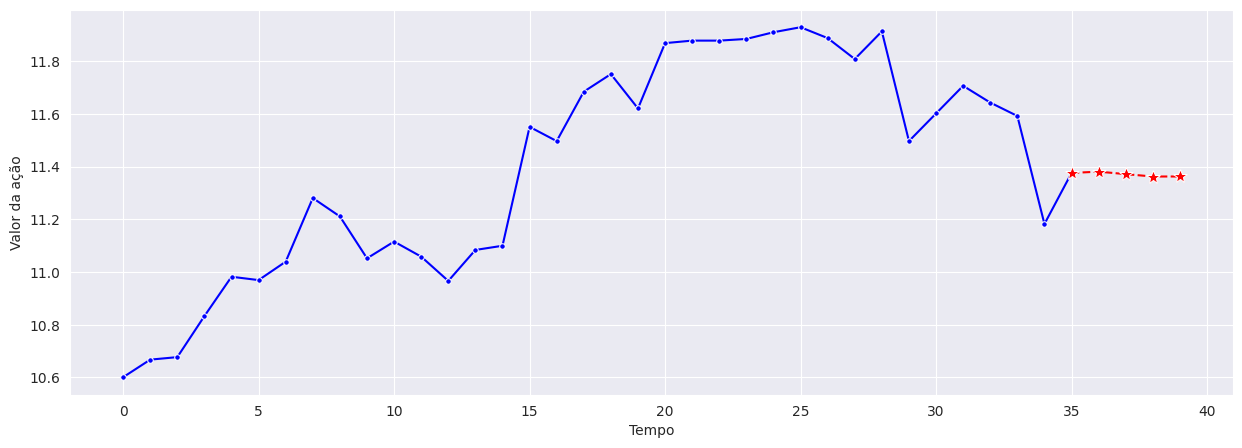

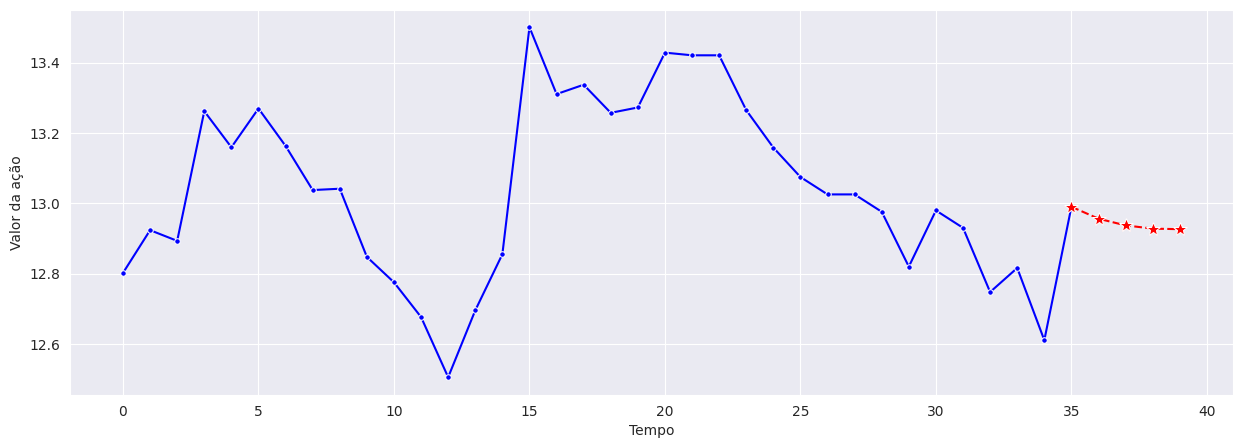

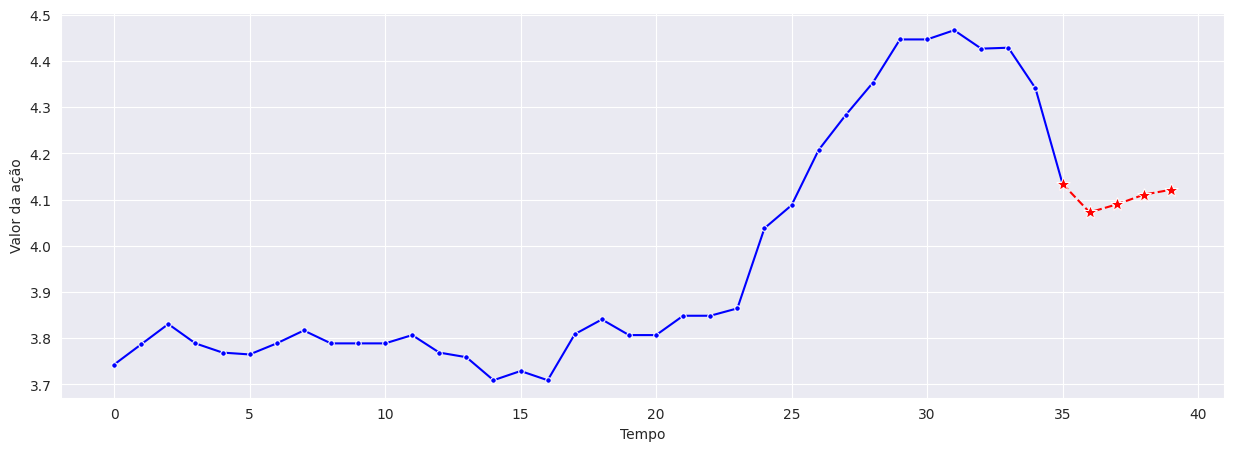

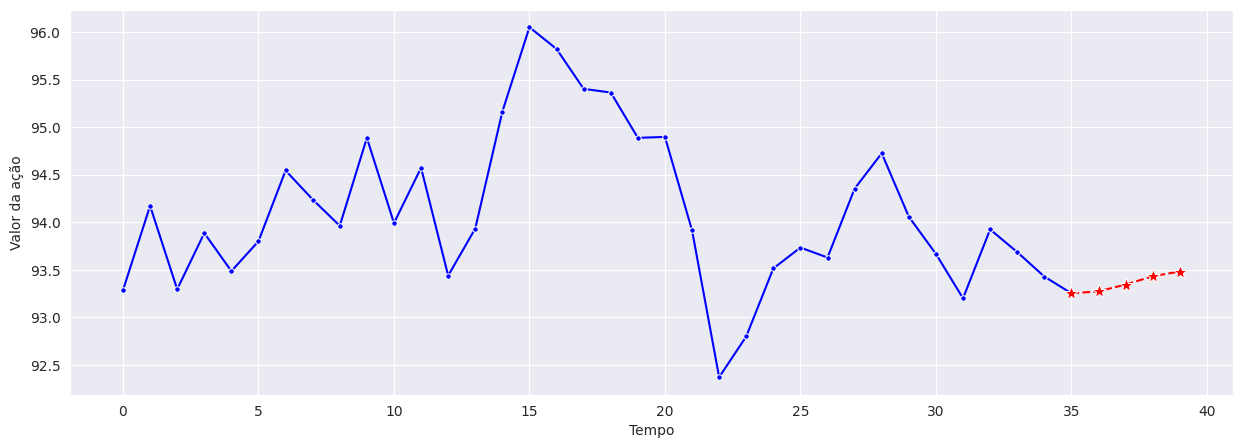

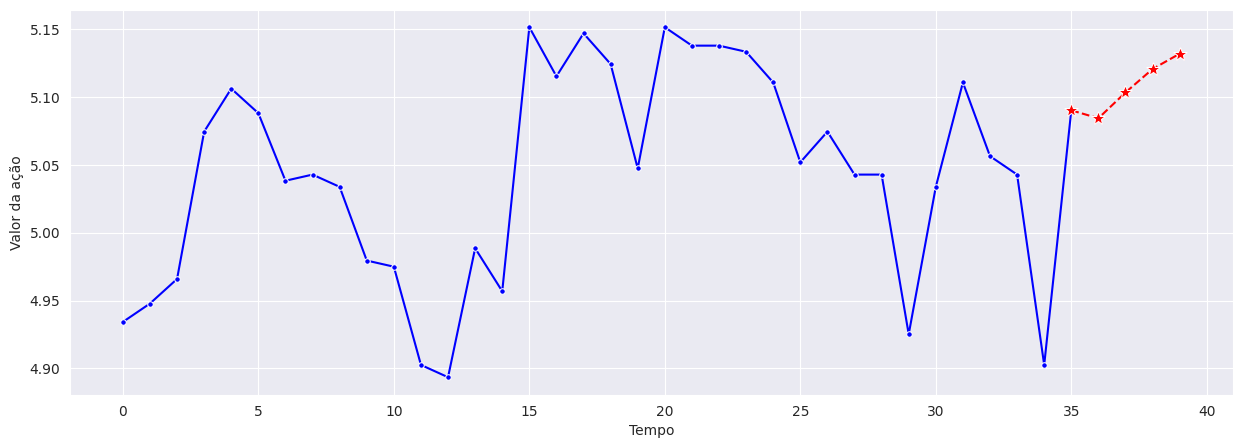

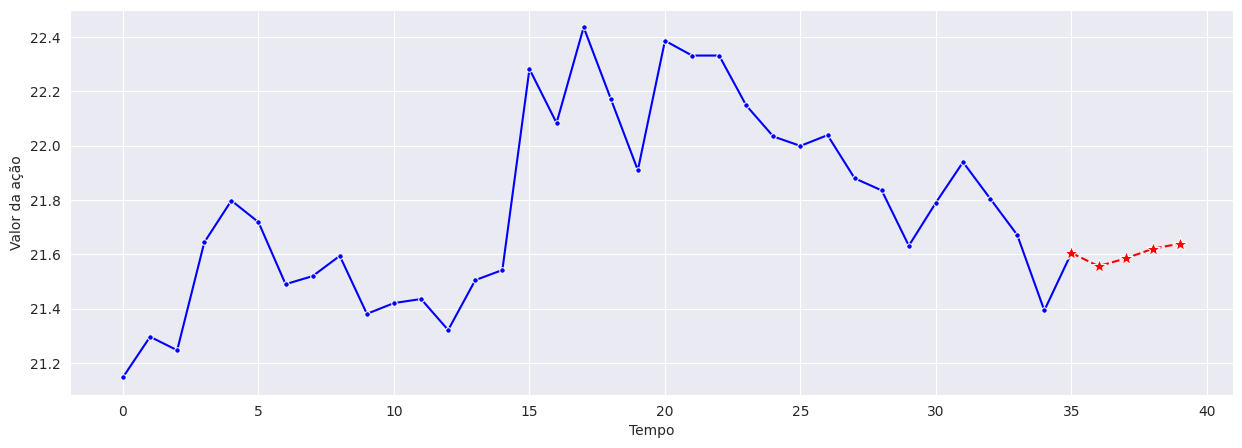

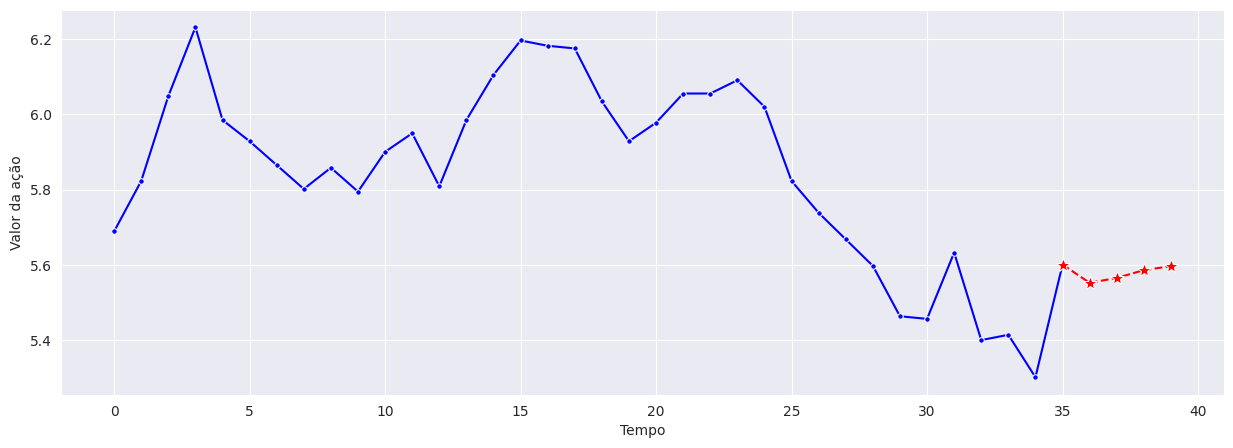

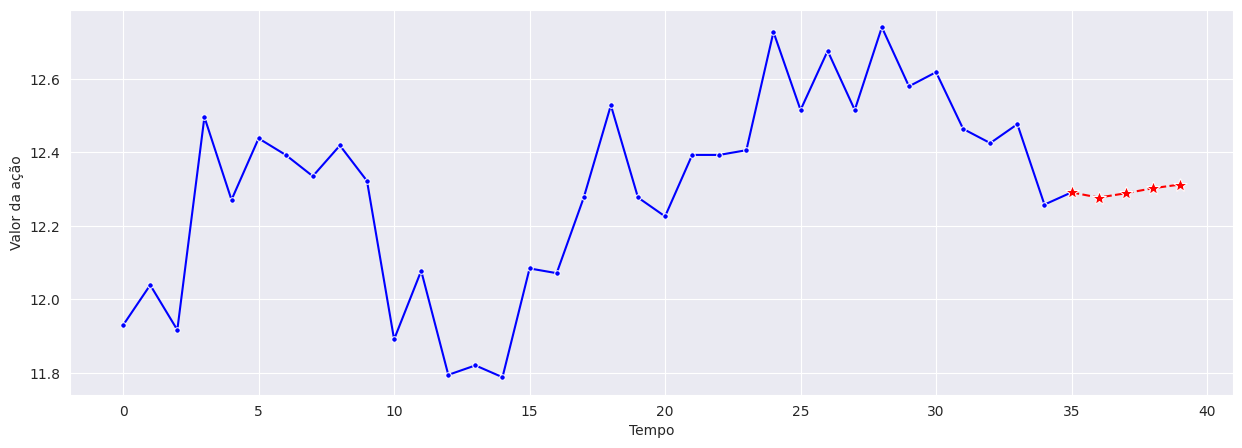

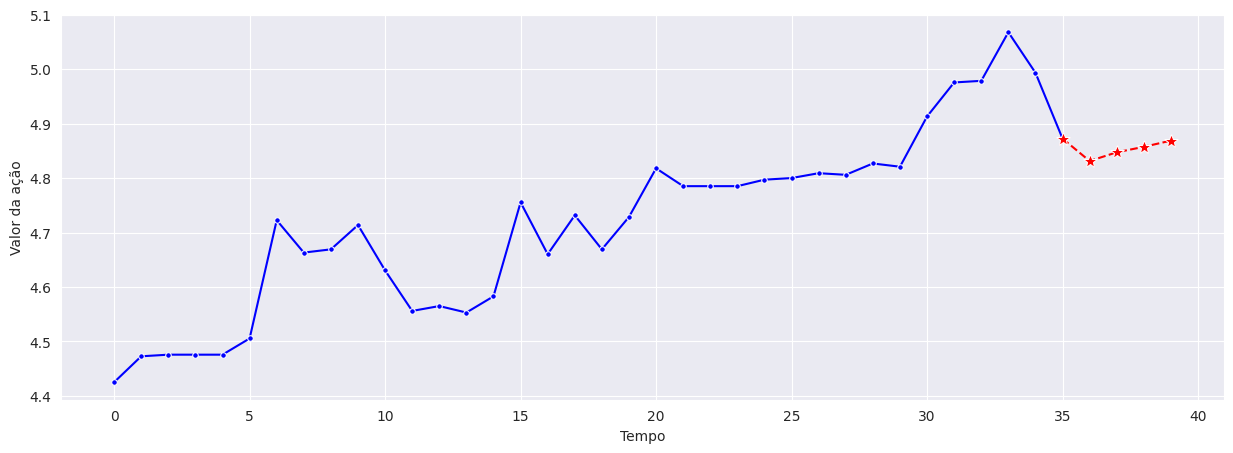

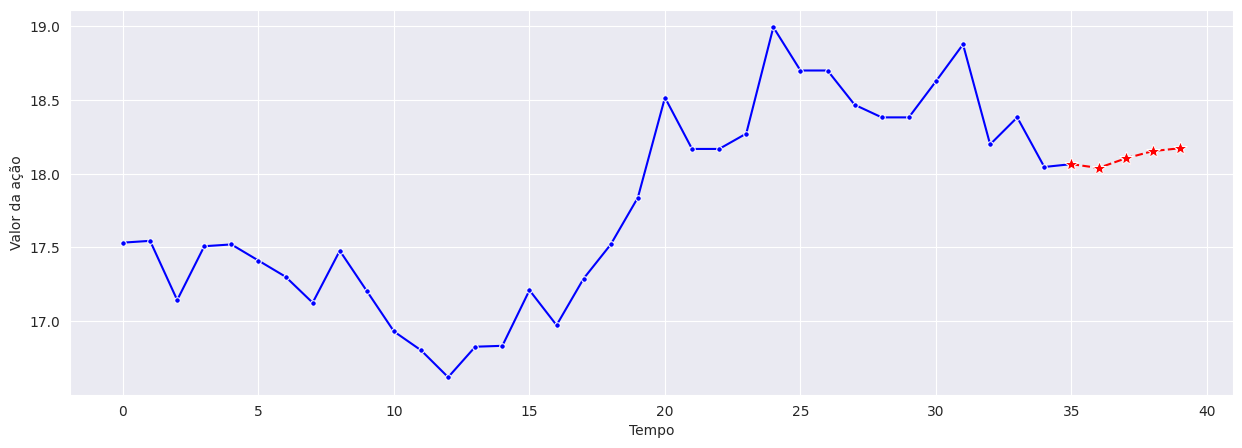

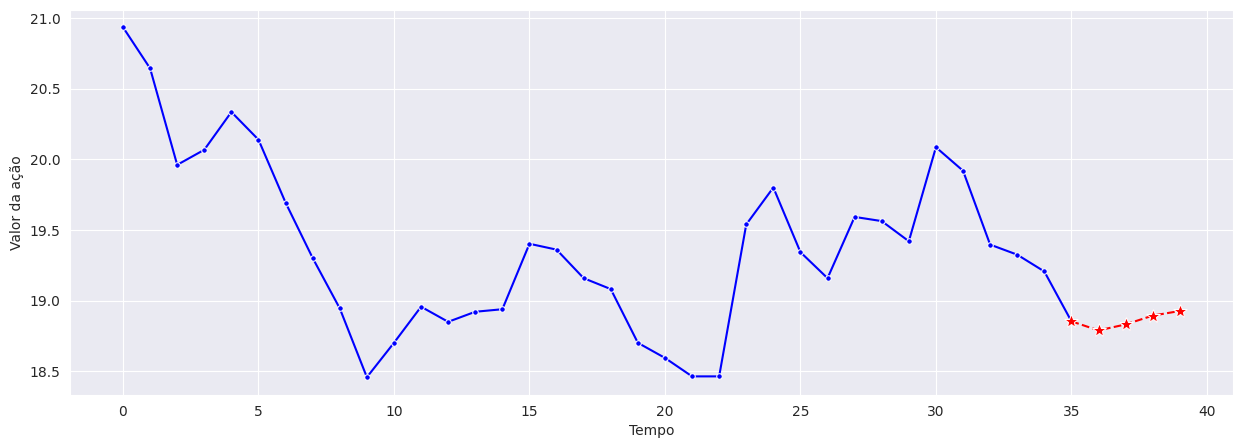

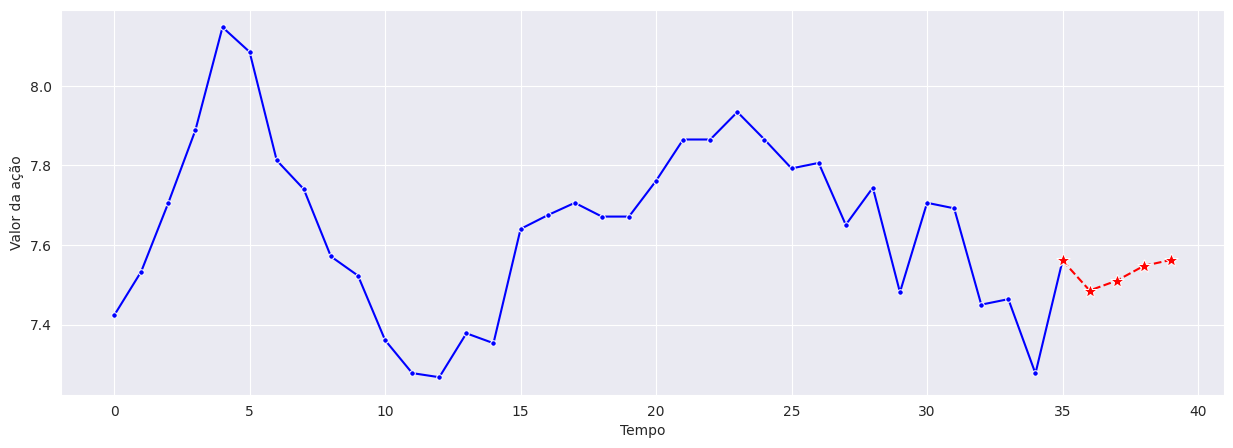

In [5]:
# =============================================================================
# DADOS
# =============================================================================

# Garantindo os paths corretos
DIR_PROJECT = get_path_project()
assert isinstance(DIR_PROJECT, Path)

STAGED = DIR_PROJECT / "data/staged"

dataset_path = STAGED / "model_training/custom_dataset.pth"
dataset = torch.load(f=dataset_path, weights_only=False)

indice_amostra = np.random.randint(low=0, high=dataset.__len__())
X_exemplo, y_exemplo = dataset.__getitem__(idx=indice_amostra)


df = pd.concat([pd.DataFrame(X_exemplo), pd.DataFrame(y_exemplo)])
df["nature"] = "true"

device = "cuda" if torch.cuda.is_available() else "cpu"
X_exemplo, y_exemplo = X_exemplo.to(device), y_exemplo.to(device)

# =============================================================================
# MODELO
# =============================================================================

model_name = "ProductionModel"
version = None

model, scaler = load_model_and_scaler(
    model_name=model_name, version=version
)

model.to(device)
model.eval()

y_pred = model(X_exemplo.unsqueeze(dim=0))

# =============================================================================
# VISUALIZANDO
# =============================================================================

df_pred = pd.DataFrame(y_pred.squeeze(dim=0).cpu().detach().numpy())
df_pred["nature"] = "pred"

mixed_df = pd.concat([df, df_pred]).reset_index(drop=True)

sns.set_style("darkgrid")


in_len = 30
out_len = 5
total_len = in_len + out_len

for col in range(13):
    plt.figure(figsize=(15, 5))

    g1 = sns.lineplot(
        data=mixed_df.iloc[:total_len + 1, [col]],
        x=mixed_df.index[:total_len + 1],
        y=col,
        linestyle="-",
        marker="o",
        markersize=4,
        errorbar=None,
        color="blue"
    )

    g2 = sns.lineplot(
        data=mixed_df.iloc[total_len:, [col]],
        x=mixed_df.index[total_len:],
        y=col,
        linestyle="--",
        marker="*",
        markersize=10,
        errorbar=None,
        color="red"
    )

    # plt.xticks(ticks=[])

    plt.xlabel("Tempo")
    plt.ylabel("Valor da ação")

    plt.show()